#### NeuralNetwork vs LGBM

This notebook is responsable for comparing a lgbm model versus a neuralnetwork model

https://www.kaggle.com/competitions/playground-series-s4e1

In [1]:
import pandas as pd
import numpy as np

import sys
sys.path.append('../')
from sand import eda

train_df = pd.read_csv('data/churn/train.csv')

In [2]:
# Define the specific dates range
start_date = "2023-06-01"
end_date = "2023-09-30"

safra = []
# Generate a random date within the specified range
for i in range(train_df.shape[0]):
    safra.append(
        pd.to_datetime(
            np.random.choice(pd.date_range(start=start_date, end=end_date))
        ).strftime("%Y%m")
    )

train_df["safra"] = safra

In [3]:
sandeda = eda.SandEDA(train_df, "Exited", "safra", "CustomerId")
sandeda.report('Churn_0_0_1')

In [4]:
from sklearn.preprocessing import LabelEncoder

# Identify object type columns in train and test
obj_cols = train_df.select_dtypes(include='object').columns

# Apply LabelEncoder to each object column
le_dict = {}
for col in obj_cols:
    le = LabelEncoder()
    # Fit on train and transform both train and test
    train_df[col] = le.fit_transform(train_df[col])
    le_dict[col] = le

In [5]:
from sklearn.model_selection import train_test_split

# Split train_df into train and test sets
train, test = train_test_split(train_df, test_size=0.2, random_state=42)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (132027, 15)
Test shape: (33007, 15)



Model version

| Modelo        | Estragegia        |
|---------------|-----------------|
| LGBM          |  Parametros padrao  |
| MLP |  1 hidden layer, 16 neuronios, sem batch size |
| MLP |  1 hidden layer, 16 neuronios, com batch size 32 |
| MLP |  2 hidden layer, 16 neuronios, com batch size 32 |
| MLP |  2 hidden layer, 32 neuronios, com batch size 32 , dropout 0.3|

Metrica de avaliacao GINI

In [6]:
results_dict = {"Modelo" : [],
                "Tempo (s)" : [],
                "Gini" : []}

#### 1. LGBM Default

In [7]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import time

start_time = time.time()

# Prepare features and target
features = [col for col in train_df.columns if col not in ['id', 'CustomerId', 'Surname', 'Exited', 'safra']]
X_train = train[features]
y_train = train['Exited']
X_test = test[features]
y_test = test['Exited']

clf = lgb.LGBMClassifier(random_state=42)
model = clf.fit(X_train, y_train)

end_time = time.time()

# Predict and evaluate
y_pred = model.predict(X_test)

# Predict probabilities for ROC AUC
y_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
gini = 2 * roc_auc - 1

print(f"Gini: {gini:.4f}")

results_dict["Modelo"].append("LGBM Default")
results_dict["Gini"].append(gini)
results_dict["Tempo (s)"].append(end_time - start_time)


[LightGBM] [Info] Number of positive: 27966, number of negative: 104061
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 859
[LightGBM] [Info] Number of data points in the train set: 132027, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.211820 -> initscore=-1.313988
[LightGBM] [Info] Start training from score -1.313988
Gini: 0.7818


In [8]:
params_df = pd.DataFrame([model.get_params()])
params_df.T

,0
boosting_type,gbdt
class_weight,None
colsample_bytree,1.0
importance_type,split
learning_rate,0.1
max_depth,-1
min_child_samples,20
min_child_weight,0.001
min_split_gain,0.0
n_estimators,100


##### 1. LGBM Default - Explicability

/home/lucas/Projects/data-sci-portfolio/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/lucas/Projects/data-sci-portfolio/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


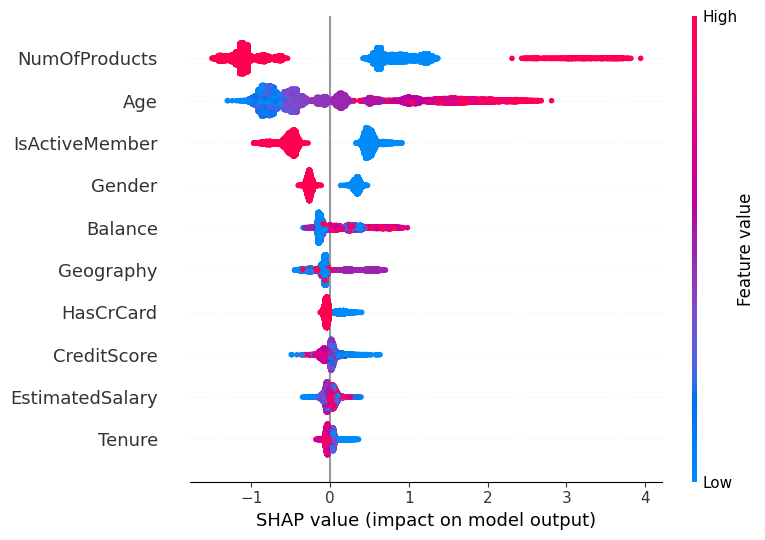

In [9]:
import shap

# Take a 20k sample from X_test
sample_X = X_test.sample(n=20000, random_state=42)

# Create SHAP explainer and values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample_X)

# Summary plot
shap.summary_plot(shap_values, sample_X)

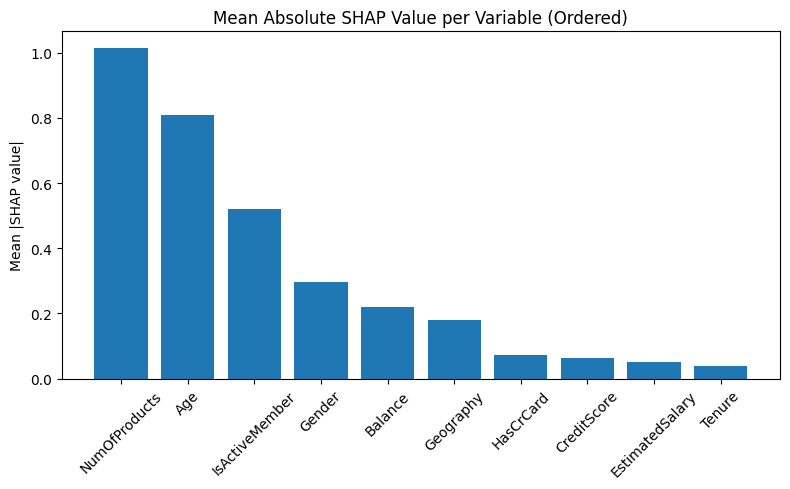

In [10]:
import numpy as np
import matplotlib.pyplot as plt

mean_abs_shap = np.abs(shap_values).mean(axis=0)
# Sort features and mean_abs_shap by descending mean_abs_shap
sorted_idx = np.argsort(mean_abs_shap)[::-1]
sorted_features = [features[i] for i in sorted_idx]
sorted_mean_abs_shap = mean_abs_shap[sorted_idx]

plt.figure(figsize=(8, 5))
plt.bar(sorted_features, sorted_mean_abs_shap)
plt.xticks(rotation=45)
plt.ylabel("Mean |SHAP value|")
plt.title("Mean Absolute SHAP Value per Variable (Ordered)")
plt.tight_layout()
plt.show()

#### 2. NeuralNetwork

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
import torch
from sklearn.metrics import roc_auc_score
import torch.nn as nn
import torch.optim as optim

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

##### 2.1 NeuralNetwork - 1 HC 16 neuronios

In [13]:
start_time = time.time()

torch.manual_seed(42)
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)
        self.sigmoid2 = nn.Sigmoid()


    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid2(x)
        return x

model = Net()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 200

loss_history = []
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs.squeeze(), y_train_tensor.float())
    loss.backward()
    optimizer.step()
    if (epoch+1) % 2 == 0:
        loss_history.append(loss.item())
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")


with torch.no_grad():
    outputs = model(X_test_tensor)
    # Calculate Gini coefficient for the neural network
    nn_proba = outputs.detach().cpu().numpy().squeeze()
    gini_nn = 2 * roc_auc_score(y_test_tensor.cpu().numpy(), nn_proba) - 1
    print(f"Gini (NN): {gini_nn:.4f}")

end_time = time.time()
    
results_dict["Modelo"].append("NN 1HC 32")
results_dict["Gini"].append(gini_nn)
results_dict["Tempo (s)"].append(end_time - start_time)


Epoch 2/200, Loss: 0.7363
Epoch 4/200, Loss: 0.7314
Epoch 6/200, Loss: 0.7266
Epoch 8/200, Loss: 0.7220
Epoch 10/200, Loss: 0.7174
Epoch 12/200, Loss: 0.7129
Epoch 14/200, Loss: 0.7085
Epoch 16/200, Loss: 0.7042
Epoch 18/200, Loss: 0.7000
Epoch 20/200, Loss: 0.6959
Epoch 22/200, Loss: 0.6919
Epoch 24/200, Loss: 0.6879
Epoch 26/200, Loss: 0.6840
Epoch 28/200, Loss: 0.6803
Epoch 30/200, Loss: 0.6766
Epoch 32/200, Loss: 0.6729
Epoch 34/200, Loss: 0.6694
Epoch 36/200, Loss: 0.6659
Epoch 38/200, Loss: 0.6625
Epoch 40/200, Loss: 0.6592
Epoch 42/200, Loss: 0.6559
Epoch 44/200, Loss: 0.6527
Epoch 46/200, Loss: 0.6495
Epoch 48/200, Loss: 0.6465
Epoch 50/200, Loss: 0.6434
Epoch 52/200, Loss: 0.6405
Epoch 54/200, Loss: 0.6376
Epoch 56/200, Loss: 0.6348
Epoch 58/200, Loss: 0.6320
Epoch 60/200, Loss: 0.6292
Epoch 62/200, Loss: 0.6266
Epoch 64/200, Loss: 0.6239
Epoch 66/200, Loss: 0.6214
Epoch 68/200, Loss: 0.6189
Epoch 70/200, Loss: 0.6164
Epoch 72/200, Loss: 0.6140
Epoch 74/200, Loss: 0.6116
Epoch

##### 2.1 NeuralNetwork - Explicability

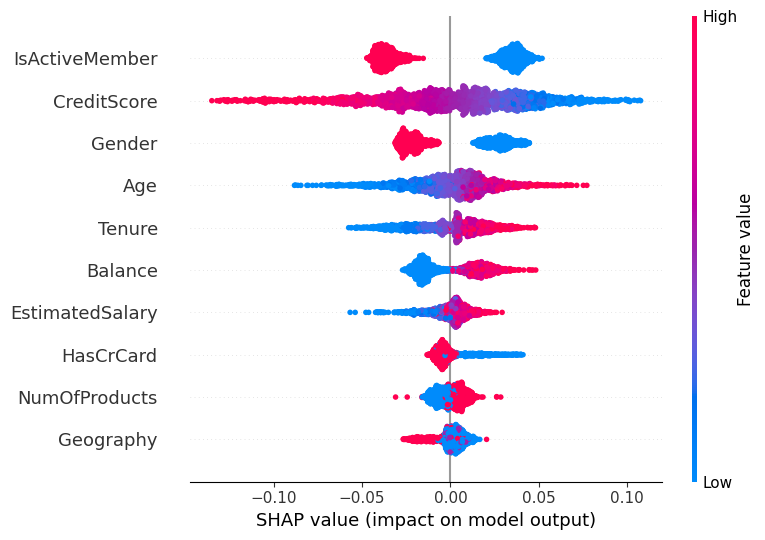

In [14]:
import shap

# Use a small sample for SHAP due to performance
sample_X = X_test_tensor[:2000]

explainer_nn = shap.DeepExplainer(model, sample_X)
shap_values_nn = explainer_nn.shap_values(sample_X)


# Beeswarm plot for neural network SHAP values
shap.summary_plot(shap_values_nn.squeeze(-1), sample_X, feature_names=features, plot_type="dot")


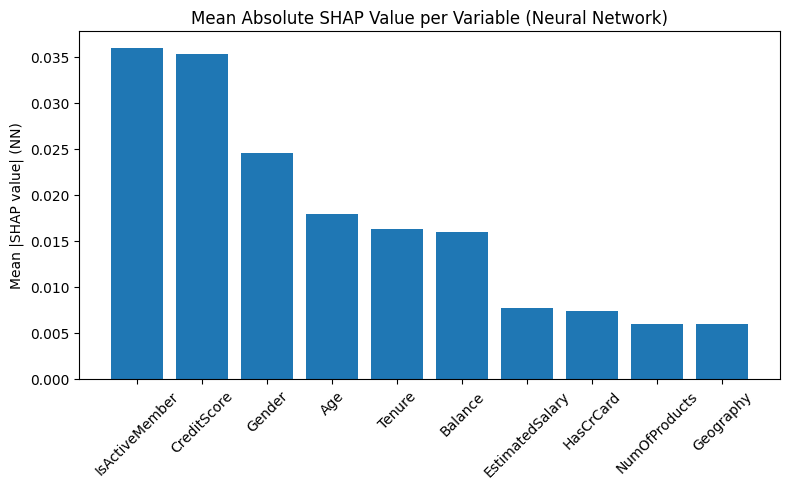

In [15]:
import numpy as np

import matplotlib.pyplot as plt

# Compute mean absolute SHAP value for each feature
mean_abs_shap_nn = np.mean(np.abs(shap_values_nn.squeeze()), axis=0)

# Sort features by importance
sorted_idx_nn = np.argsort(mean_abs_shap_nn)[::-1]
sorted_features_nn = [features[i] for i in sorted_idx_nn]
sorted_mean_abs_shap_nn = mean_abs_shap_nn[sorted_idx_nn]

plt.figure(figsize=(8, 5))
plt.bar(sorted_features_nn, sorted_mean_abs_shap_nn)
plt.xticks(rotation=45)
plt.ylabel("Mean |SHAP value| (NN)")
plt.title("Mean Absolute SHAP Value per Variable (Neural Network)")
plt.tight_layout()
plt.show()

##### 2.2 NeuralNetwork - 1 HC 16 neuronios batch size 252

In [16]:
start_time = time.time()

torch.manual_seed(42)
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)
        self.sigmoid2 = nn.Sigmoid()


    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid2(x)
        return x

model = Net()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 200

batch_size = 252

loss_history = []
for epoch in range(epochs):
    for i in range(0, X_train_tensor.size(0), batch_size):
        batch_x = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs.squeeze(), batch_y.float())

        loss.backward()
        optimizer.step()
    if (epoch+1) % 2 == 0:
        loss_history.append(loss.item())
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

with torch.no_grad():
    outputs = model(X_test_tensor)
    # Calculate Gini coefficient for the neural network
    nn_proba = outputs.detach().cpu().numpy().squeeze()
    gini_nn = 2 * roc_auc_score(y_test_tensor.cpu().numpy(), nn_proba) - 1
    print(f"Gini (NN): {gini_nn:.4f}")

end_time = time.time()
results_dict["Modelo"].append("NN 1HC 16 batch 32")
results_dict["Gini"].append(gini_nn)
results_dict["Tempo (s)"].append(end_time - start_time)

Epoch 2/200, Loss: 0.4300
Epoch 4/200, Loss: 0.4167
Epoch 6/200, Loss: 0.4154
Epoch 8/200, Loss: 0.4124
Epoch 10/200, Loss: 0.4079
Epoch 12/200, Loss: 0.4031
Epoch 14/200, Loss: 0.3982
Epoch 16/200, Loss: 0.3932
Epoch 18/200, Loss: 0.3888
Epoch 20/200, Loss: 0.3854
Epoch 22/200, Loss: 0.3833
Epoch 24/200, Loss: 0.3819
Epoch 26/200, Loss: 0.3815
Epoch 28/200, Loss: 0.3819
Epoch 30/200, Loss: 0.3827
Epoch 32/200, Loss: 0.3836
Epoch 34/200, Loss: 0.3845
Epoch 36/200, Loss: 0.3853
Epoch 38/200, Loss: 0.3861
Epoch 40/200, Loss: 0.3868
Epoch 42/200, Loss: 0.3875
Epoch 44/200, Loss: 0.3882
Epoch 46/200, Loss: 0.3888
Epoch 48/200, Loss: 0.3893
Epoch 50/200, Loss: 0.3898
Epoch 52/200, Loss: 0.3902
Epoch 54/200, Loss: 0.3905
Epoch 56/200, Loss: 0.3908
Epoch 58/200, Loss: 0.3911
Epoch 60/200, Loss: 0.3913
Epoch 62/200, Loss: 0.3916
Epoch 64/200, Loss: 0.3917
Epoch 66/200, Loss: 0.3919
Epoch 68/200, Loss: 0.3920
Epoch 70/200, Loss: 0.3921
Epoch 72/200, Loss: 0.3921
Epoch 74/200, Loss: 0.3921
Epoch

##### 2.3 NeuralNetwork - 2 HC 16 neuronios batch size 252

In [17]:
start_time = time.time()

torch.manual_seed(42)
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 16)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()


    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

model = Net()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 200

batch_size = 252

loss_history = []
for epoch in range(epochs):
    for i in range(0, X_train_tensor.size(0), batch_size):
        batch_x = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs.squeeze(), batch_y.float())

        loss.backward()
        optimizer.step()
    if (epoch+1) % 2 == 0:
        loss_history.append(loss.item())
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

with torch.no_grad():
    outputs = model(X_test_tensor)
    # Calculate Gini coefficient for the neural network
    nn_proba = outputs.detach().cpu().numpy().squeeze()
    gini_nn = 2 * roc_auc_score(y_test_tensor.cpu().numpy(), nn_proba) - 1
    print(f"Gini (NN): {gini_nn:.4f}")

end_time = time.time()
results_dict["Modelo"].append("NN 2HC 16 batch 252")
results_dict["Gini"].append(gini_nn)
results_dict["Tempo (s)"].append(end_time - start_time)

Epoch 2/200, Loss: 0.4480
Epoch 4/200, Loss: 0.4103
Epoch 6/200, Loss: 0.4013
Epoch 8/200, Loss: 0.3948
Epoch 10/200, Loss: 0.3862
Epoch 12/200, Loss: 0.3801
Epoch 14/200, Loss: 0.3768
Epoch 16/200, Loss: 0.3765
Epoch 18/200, Loss: 0.3772
Epoch 20/200, Loss: 0.3779
Epoch 22/200, Loss: 0.3784
Epoch 24/200, Loss: 0.3787
Epoch 26/200, Loss: 0.3791
Epoch 28/200, Loss: 0.3792
Epoch 30/200, Loss: 0.3793
Epoch 32/200, Loss: 0.3794
Epoch 34/200, Loss: 0.3792
Epoch 36/200, Loss: 0.3791
Epoch 38/200, Loss: 0.3790
Epoch 40/200, Loss: 0.3786
Epoch 42/200, Loss: 0.3781
Epoch 44/200, Loss: 0.3774
Epoch 46/200, Loss: 0.3768
Epoch 48/200, Loss: 0.3761
Epoch 50/200, Loss: 0.3751
Epoch 52/200, Loss: 0.3743
Epoch 54/200, Loss: 0.3734
Epoch 56/200, Loss: 0.3725
Epoch 58/200, Loss: 0.3716
Epoch 60/200, Loss: 0.3709
Epoch 62/200, Loss: 0.3701
Epoch 64/200, Loss: 0.3696
Epoch 66/200, Loss: 0.3691
Epoch 68/200, Loss: 0.3686
Epoch 70/200, Loss: 0.3681
Epoch 72/200, Loss: 0.3675
Epoch 74/200, Loss: 0.3668
Epoch

##### 2.4 NeuralNetwork - 2 HC 32 neuronios batch size 252

In [18]:
start_time = time.time()

torch.manual_seed(42)
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()


    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

model = Net()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 200

batch_size = 252

loss_history = []
for epoch in range(epochs):
    for i in range(0, X_train_tensor.size(0), batch_size):
        batch_x = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs.squeeze(), batch_y.float())

        loss.backward()
        optimizer.step()
    if (epoch+1) % 2 == 0:
        loss_history.append(loss.item())
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

with torch.no_grad():
    outputs = model(X_test_tensor)
    # Calculate Gini coefficient for the neural network
    nn_proba = outputs.detach().cpu().numpy().squeeze()
    gini_nn = 2 * roc_auc_score(y_test_tensor.cpu().numpy(), nn_proba) - 1
    print(f"Gini (NN): {gini_nn:.4f}")

end_time = time.time()
results_dict["Modelo"].append("NN 2HC 32 batch 252")
results_dict["Gini"].append(gini_nn)
results_dict["Tempo (s)"].append(end_time - start_time)

Epoch 2/200, Loss: 0.4560
Epoch 4/200, Loss: 0.4142
Epoch 6/200, Loss: 0.4052
Epoch 8/200, Loss: 0.3975
Epoch 10/200, Loss: 0.3896
Epoch 12/200, Loss: 0.3842
Epoch 14/200, Loss: 0.3824
Epoch 16/200, Loss: 0.3823
Epoch 18/200, Loss: 0.3833
Epoch 20/200, Loss: 0.3842
Epoch 22/200, Loss: 0.3853
Epoch 24/200, Loss: 0.3864
Epoch 26/200, Loss: 0.3874
Epoch 28/200, Loss: 0.3881
Epoch 30/200, Loss: 0.3885
Epoch 32/200, Loss: 0.3886
Epoch 34/200, Loss: 0.3885
Epoch 36/200, Loss: 0.3881
Epoch 38/200, Loss: 0.3877
Epoch 40/200, Loss: 0.3872
Epoch 42/200, Loss: 0.3867
Epoch 44/200, Loss: 0.3862
Epoch 46/200, Loss: 0.3856
Epoch 48/200, Loss: 0.3852
Epoch 50/200, Loss: 0.3848
Epoch 52/200, Loss: 0.3843
Epoch 54/200, Loss: 0.3840
Epoch 56/200, Loss: 0.3835
Epoch 58/200, Loss: 0.3828
Epoch 60/200, Loss: 0.3822
Epoch 62/200, Loss: 0.3816
Epoch 64/200, Loss: 0.3808
Epoch 66/200, Loss: 0.3800
Epoch 68/200, Loss: 0.3791
Epoch 70/200, Loss: 0.3781
Epoch 72/200, Loss: 0.3771
Epoch 74/200, Loss: 0.3763
Epoch

##### 2.5 NeuralNetwork - 2 HC 32 neuronios batch size 252 dropout 0.3

In [19]:
start_time = time.time()

torch.manual_seed(42)
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()


    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

model = Net()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
epochs = 200
batch_size = 252

dropout = nn.Dropout(p=0.3)  # Dropout layer with 0.3 probability

loss_history = []
for epoch in range(epochs):
    for i in range(0, X_train_tensor.size(0), batch_size):
        batch_x = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]

        optimizer.zero_grad()
        x = model.fc1(batch_x)
        x = model.relu(x)
        x = dropout(x)
        x = model.fc2(x)
        x = model.relu2(x)
        x = dropout(x)
        x = model.fc3(x)
        outputs = model.sigmoid(x)

        loss = criterion(outputs.squeeze(), batch_y.float())
        loss.backward()
        optimizer.step()
    if (epoch+1) % 2 == 0:
        loss_history.append(loss.item())
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

with torch.no_grad():
    x = model.fc1(X_test_tensor)
    x = model.relu(x)
    x = model.fc2(x)
    x = model.relu2(x)
    x = model.fc3(x)
    outputs = model.sigmoid(x)
    nn_proba = outputs.detach().cpu().numpy().squeeze()
    gini_nn = 2 * roc_auc_score(y_test_tensor.cpu().numpy(), nn_proba) - 1
    print(f"Gini (NN): {gini_nn:.4f}")

end_time = time.time()
results_dict["Modelo"].append("NN 2HC 32 batch 252 dropout 0.3")
results_dict["Gini"].append(gini_nn)
results_dict["Tempo (s)"].append(end_time - start_time)

Epoch 2/200, Loss: 0.4680
Epoch 4/200, Loss: 0.4409
Epoch 6/200, Loss: 0.4097
Epoch 8/200, Loss: 0.4355
Epoch 10/200, Loss: 0.4076
Epoch 12/200, Loss: 0.4070
Epoch 14/200, Loss: 0.4076
Epoch 16/200, Loss: 0.3910
Epoch 18/200, Loss: 0.4322
Epoch 20/200, Loss: 0.4257
Epoch 22/200, Loss: 0.3985
Epoch 24/200, Loss: 0.4121
Epoch 26/200, Loss: 0.3886
Epoch 28/200, Loss: 0.3793
Epoch 30/200, Loss: 0.3799
Epoch 32/200, Loss: 0.4217
Epoch 34/200, Loss: 0.4117
Epoch 36/200, Loss: 0.3888
Epoch 38/200, Loss: 0.4010
Epoch 40/200, Loss: 0.4004
Epoch 42/200, Loss: 0.4032
Epoch 44/200, Loss: 0.3768
Epoch 46/200, Loss: 0.3979
Epoch 48/200, Loss: 0.4039
Epoch 50/200, Loss: 0.3761
Epoch 52/200, Loss: 0.3937
Epoch 54/200, Loss: 0.3687
Epoch 56/200, Loss: 0.3966
Epoch 58/200, Loss: 0.3935
Epoch 60/200, Loss: 0.3983
Epoch 62/200, Loss: 0.3894
Epoch 64/200, Loss: 0.4101
Epoch 66/200, Loss: 0.3887
Epoch 68/200, Loss: 0.3789
Epoch 70/200, Loss: 0.4108
Epoch 72/200, Loss: 0.3950
Epoch 74/200, Loss: 0.3942
Epoch

##### 2.6 NeuralNetwork - 2 HC 32 neuronios batch size 252 dropout 0.3 mom 0.9 wd 1e-5

In [20]:
start_time = time.time()

torch.manual_seed(42)
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()


    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

model = Net()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-5)
epochs = 200
batch_size = 252

dropout = nn.Dropout(p=0.3)  # Dropout layer with 0.3 probability

loss_history = []
for epoch in range(epochs):
    for i in range(0, X_train_tensor.size(0), batch_size):
        batch_x = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]

        optimizer.zero_grad()
        x = model.fc1(batch_x)
        x = model.relu(x)
        x = dropout(x)
        x = model.fc2(x)
        x = model.relu2(x)
        x = dropout(x)
        x = model.fc3(x)
        outputs = model.sigmoid(x)

        loss = criterion(outputs.squeeze(), batch_y.float())
        loss.backward()
        optimizer.step()
    if (epoch+1) % 2 == 0:
        loss_history.append(loss.item())
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

with torch.no_grad():
    x = model.fc1(X_test_tensor)
    x = model.relu(x)
    x = model.fc2(x)
    x = model.relu2(x)
    x = model.fc3(x)
    outputs = model.sigmoid(x)
    nn_proba = outputs.detach().cpu().numpy().squeeze()
    gini_nn = 2 * roc_auc_score(y_test_tensor.cpu().numpy(), nn_proba) - 1
    print(f"Gini (NN): {gini_nn:.4f}")

end_time = time.time()
results_dict["Modelo"].append("NN 2HC 32 batch 252 dropout 0.3 mom 0.9 wd 1e-5")
results_dict["Gini"].append(gini_nn)
results_dict["Tempo (s)"].append(end_time - start_time)

Epoch 2/200, Loss: 0.3990
Epoch 4/200, Loss: 0.4069
Epoch 6/200, Loss: 0.3831
Epoch 8/200, Loss: 0.3988
Epoch 10/200, Loss: 0.3690
Epoch 12/200, Loss: 0.3806
Epoch 14/200, Loss: 0.4069
Epoch 16/200, Loss: 0.3764
Epoch 18/200, Loss: 0.4156
Epoch 20/200, Loss: 0.3947
Epoch 22/200, Loss: 0.3987
Epoch 24/200, Loss: 0.3863
Epoch 26/200, Loss: 0.3641
Epoch 28/200, Loss: 0.3725
Epoch 30/200, Loss: 0.3733
Epoch 32/200, Loss: 0.4072
Epoch 34/200, Loss: 0.3922
Epoch 36/200, Loss: 0.3743
Epoch 38/200, Loss: 0.3897
Epoch 40/200, Loss: 0.3823
Epoch 42/200, Loss: 0.3816
Epoch 44/200, Loss: 0.3648
Epoch 46/200, Loss: 0.3737
Epoch 48/200, Loss: 0.3772
Epoch 50/200, Loss: 0.3896
Epoch 52/200, Loss: 0.3672
Epoch 54/200, Loss: 0.3501
Epoch 56/200, Loss: 0.3760
Epoch 58/200, Loss: 0.3798
Epoch 60/200, Loss: 0.3753
Epoch 62/200, Loss: 0.3797
Epoch 64/200, Loss: 0.4025
Epoch 66/200, Loss: 0.3763
Epoch 68/200, Loss: 0.3836
Epoch 70/200, Loss: 0.3732
Epoch 72/200, Loss: 0.3615
Epoch 74/200, Loss: 0.3717
Epoch

In [21]:
pd.DataFrame(results_dict)

,Modelo,Tempo (s),Gini
0,LGBM Default,0.317660,0.781790
1,NN 1HC 32,3.301013,0.381565
2,NN 1HC 16 batch 32,34.694076,0.771557
3,NN 2HC 16 batch 252,44.190777,0.778737
4,NN 2HC 32 batch 252,47.401552,0.778717
5,NN 2HC 32 batch 252 dropout 0.3,72.425791,0.772826
6,NN 2HC 32 batch 252 dropout 0.3 mom 0.9 wd 1e-5,78.715850,0.774965


##### 2.6 NeuralNetwork - Explicability

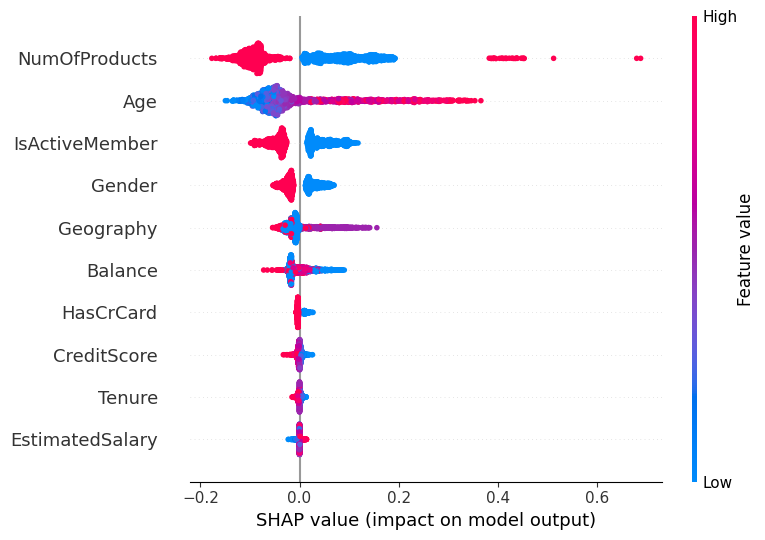

In [22]:
import shap

# Use a small sample for SHAP due to performance
sample_X = X_test_tensor[:2000]

explainer_nn = shap.DeepExplainer(model, sample_X)
shap_values_nn = explainer_nn.shap_values(sample_X)


# Beeswarm plot for neural network SHAP values
shap.summary_plot(shap_values_nn.squeeze(-1), sample_X, feature_names=features, plot_type="dot")


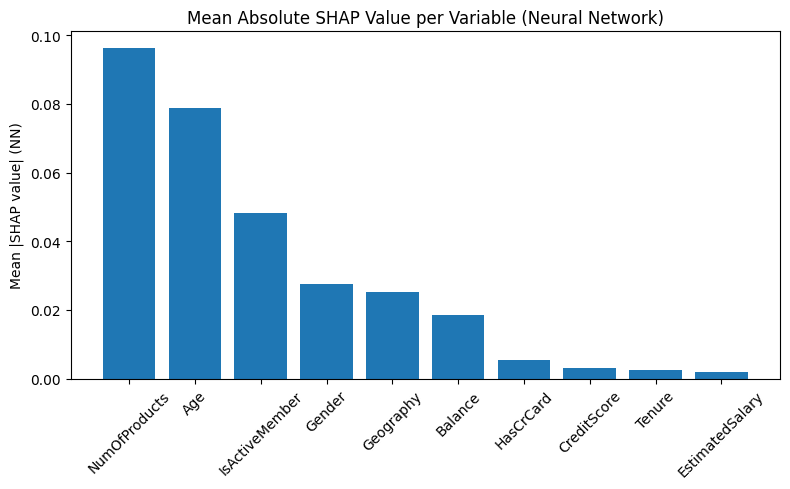

In [23]:
import numpy as np

import matplotlib.pyplot as plt

# Compute mean absolute SHAP value for each feature
mean_abs_shap_nn = np.mean(np.abs(shap_values_nn.squeeze()), axis=0)

# Sort features by importance
sorted_idx_nn = np.argsort(mean_abs_shap_nn)[::-1]
sorted_features_nn = [features[i] for i in sorted_idx_nn]
sorted_mean_abs_shap_nn = mean_abs_shap_nn[sorted_idx_nn]

plt.figure(figsize=(8, 5))
plt.bar(sorted_features_nn, sorted_mean_abs_shap_nn)
plt.xticks(rotation=45)
plt.ylabel("Mean |SHAP value| (NN)")
plt.title("Mean Absolute SHAP Value per Variable (Neural Network)")
plt.tight_layout()
plt.show()